In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

weather = pd.read_csv(path + "\Weather\Weather_Year_Average_1985_2025.csv")

In [3]:
print(weather.shape)

(41, 4)


In [4]:
weather.head()

,Year,Precipitation,AirTemperature,SunshineDuration
0,1985,80.76,9.31,104.67
1,1986,86.53,8.84,111.62
2,1987,76.00,9.68,102.71
3,1988,86.10,10.05,108.28
4,1989,70.49,10.60,122.36


In [13]:
spring_wheat = pd.read_csv(path + "\CropYield\SpringWheat1985_2025.csv")[['Year','Tonnes']]
winter_wheat = pd.read_csv(path + "\CropYield\WinterWheat1985_2025.csv")[['Year','Tonnes']]
spring_oats = pd.read_csv(path + "\CropYield\SpringOats1985_2025.csv")[['Year','Tonnes']]
winter_oats = pd.read_csv(path + "\CropYield\WinterOats1985_2025.csv")[['Year','Tonnes']]


In [6]:
spring_wheat.head()

,Year,Tonnes
0,1985,5.8
1,1986,5.4
2,1987,6.2
3,1988,7.0
4,1989,6.2


In [14]:
swheat = spring_wheat.rename(columns={'Tonnes': 'SpringWheat'})
wwheat = winter_wheat.rename(columns={'Tonnes': 'WinterWheat'})
soats = spring_oats.rename(columns={'Tonnes': 'SpringOats'})
woats = winter_oats.rename(columns={'Tonnes': 'WinterOats'})

In [15]:
df = weather.merge(swheat, on='Year').merge(wwheat, on='Year').merge(soats, on='Year').merge(woats, on='Year')

In [16]:
print(df.columns.tolist())

['Year', 'Precipitation', 'AirTemperature', 'SunshineDuration', 'SpringWheat', 'WinterWheat', 'SpringOats', 'WinterOats']


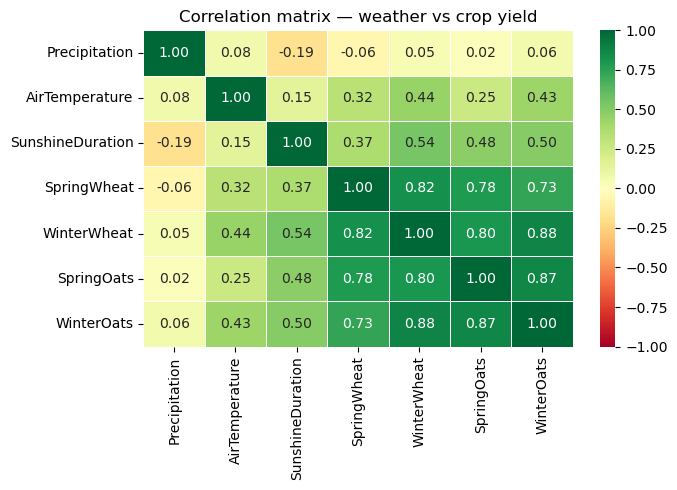

In [18]:
cols = ['Precipitation', 'AirTemperature', 'SunshineDuration', 'SpringWheat', 'WinterWheat', 'SpringOats','WinterOats']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — weather vs crop yield')
plt.tight_layout()
plt.show()

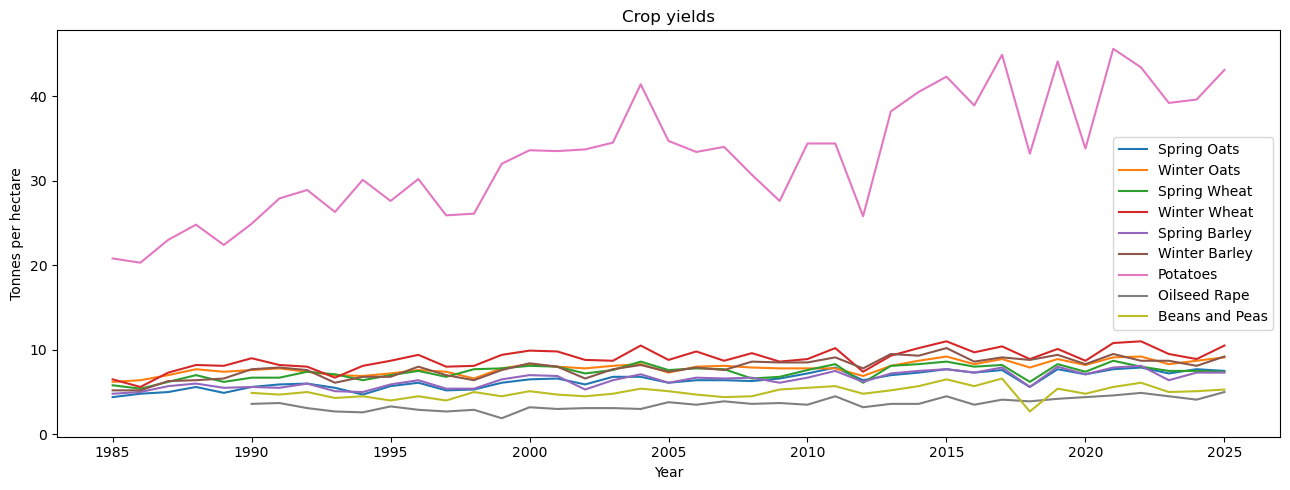

In [27]:
yields  = pd.read_csv(path +  "\CropYield\CombinedYield1985_2025.csv")
df = weather.merge(yields, on='Year')

crop_cols = ['Spring Oats', 'Winter Oats', 'Spring Wheat', 'Winter Wheat','Spring Barley', 'Winter Barley', 'Potatoes', 'Oilseed Rape', 'Beans and Peas']

fig, ax = plt.subplots(figsize=(13, 5))
for crop in crop_cols:
    ax.plot(df['Year'], df[crop], label=crop, linewidth=1.5)
ax.set_title('Crop yields')
ax.set_xlabel('Year')
ax.set_ylabel('Tonnes per hectare')
ax.legend()
plt.tight_layout()
plt.show()

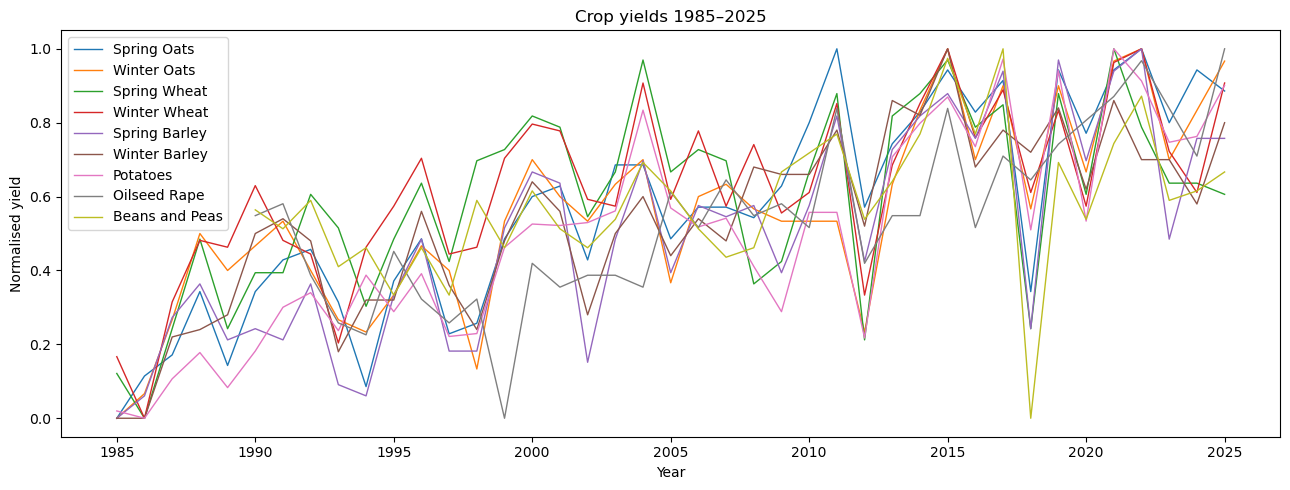

In [29]:
norm = (df[crop_cols] - df[crop_cols].min()) / (df[crop_cols].max() - df[crop_cols].min())
norm['Year'] = df['Year']

fig, ax = plt.subplots(figsize=(13, 5))
for crop in crop_cols:
    ax.plot(norm['Year'], norm[crop], label=crop, linewidth=1)
ax.set_title('Crop yields 1985–2025')
ax.set_xlabel('Year')
ax.set_ylabel('Normalised yield')
ax.legend()
plt.tight_layout()
plt.show()

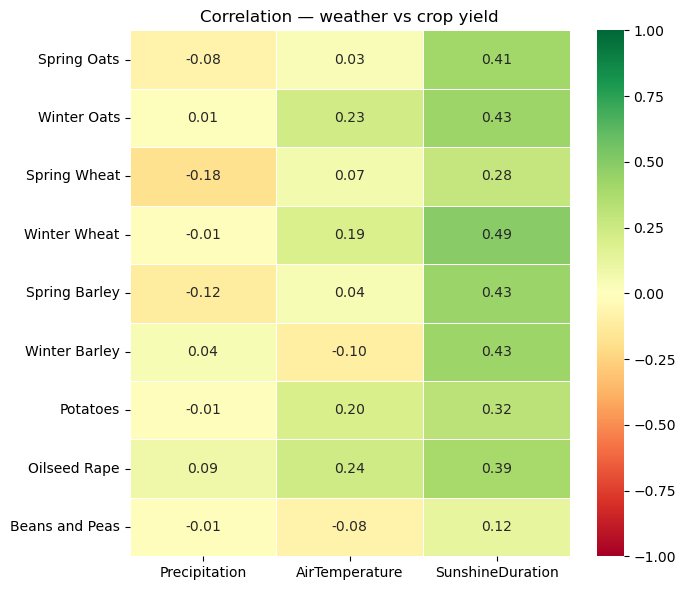

In [ ]:
weather_cols = ['Precipitation', 'AirTemperature', 'SunshineDuration']

df_clean = df[weather_cols + crop_cols].dropna()

corr = df_clean.corr().loc[crop_cols, weather_cols]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation: Weather vs Crop yield')
plt.tight_layout()
plt.show()